In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import seaborn as sns
from scipy import sparse
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

In [14]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [13]:
!ls /content/drive/MyDrive/data/elliptic_bitcoin_dataset

elliptic_bitcoin_dataset  elliptic_txs_edgelist.csv
elliptic_txs_classes.csv  elliptic_txs_features.csv


# BEFORE YOU RUN
## Data Structure Should be:
### data /
###        cyber_dataset
####                    /auth.txt.gs * very large, working on getting a workable version
####                    /redteam.txt.gz
###        elliptic_bitcoin_dataset
####                               /elliptic_txs_classes.csv
####                               /elliptic_txs_edgelist.csv
####                               /elliptic_txs_features.csv
###        keystroke_dynamics_dataset/DSL-StrongPasswordData.csv

About the Data:
- Elliptic is already a graph. It has 2% illicit data, the rest is licit.
- Few things to check out: is the data clustered in specific time windows or not?

- For device/auth signals, this data is pretty massive. We need to downsample to be able to manage number of users.
- We can explore how many users log into a single machine. Maybe a "normal" number of devices per user, things like that

- Behavioral data is micro-features for the nodes. We can analyze the variance in keystoke hold times. Maybe some sort of behavioral fingerprint for a user that changes when an account is compromised.

Mapping the Data
- These obviouslly aren't natively connected, we need to do this ourselves. For example, User_ID -> Wallet_ID and Device_ID -> Login_Session or something like that.
- This could help us map User A logs in from Device B (unusual) with a typing cadence that doesn't match their profile, then immediately sends Bitcoin to an Illicit node in the Elliptic graph

In [19]:
!ln -s "/content/drive/MyDrive/data" /content/data

In [20]:
# Read in the Datasets
df_labels = pd.read_csv('data/elliptic_bitcoin_dataset/elliptic_txs_classes.csv') # maps transaction IDs to licit, illicit, unknown
df_edges = pd.read_csv('data/elliptic_bitcoin_dataset/elliptic_txs_edgelist.csv') # the adjacency list [who sent money to who]
df_features = pd.read_csv('data/elliptic_bitcoin_dataset/elliptic_txs_features.csv', header=None) # 166 features for each transaction

In [26]:
# 1. Rename columns for clarity
# The features file usually doesn't have headers. Column 0 is the ID, Column 1 is Time Step.
df_features.columns = ['txId', 'time_step'] + [f'feat_{i}' for i in range(165)]

# 2. Merge labels and features into a master Node Dataframe
df_nodes = pd.merge(df_features, df_labels, on='txId')

In [30]:
class_map = {'1': 1, '2': 0, 'unknown': -1}
df_nodes["y"] = df_nodes["class"].astype(int)

print(df_nodes["y"].value_counts())
# We have a lot of unknown nodes we can work with. Train on the known ones and see if we can classify the unknowns later

y
-1    157205
 0     42019
 1      4545
Name: count, dtype: int64


In [31]:
df_nodes.head()

,txId,time_step,feat_0,feat_1,feat_2,feat_3,feat_4,feat_5,feat_6,feat_7,...,feat_157,feat_158,feat_159,feat_160,feat_161,feat_162,feat_163,feat_164,class,y
0,230425980,1,-0.171469,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162097,...,1.461330,1.461369,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792,-1,-1
1,5530458,1,-0.171484,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162112,...,-0.979074,-0.978556,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792,-1,-1
2,232022460,1,-0.172107,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162749,...,-0.979074,-0.978556,-0.098889,-0.106715,-0.131155,-0.183671,-0.120613,-0.119792,-1,-1
3,232438397,1,0.163054,1.963790,-0.646376,12.409294,-0.063725,9.782742,12.414558,-0.163645,...,0.241128,0.241406,1.072793,0.085530,-0.131155,0.677799,-0.120613,-0.119792,0,0
4,230460314,1,1.011523,-0.081127,-1.201369,1.153668,0.333276,1.312656,-0.061584,-0.163523,...,0.517257,0.579382,0.018279,0.277775,0.326394,1.293750,0.178136,0.179117,-1,-1


In [32]:
df_features.head()

,txId,time_step,feat_0,feat_1,feat_2,feat_3,feat_4,feat_5,feat_6,feat_7,...,feat_155,feat_156,feat_157,feat_158,feat_159,feat_160,feat_161,feat_162,feat_163,feat_164
0,230425980,1,-0.171469,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162097,...,-0.562153,-0.600999,1.461330,1.461369,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792
1,5530458,1,-0.171484,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162112,...,0.947382,0.673103,-0.979074,-0.978556,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792
2,232022460,1,-0.172107,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162749,...,0.670883,0.439728,-0.979074,-0.978556,-0.098889,-0.106715,-0.131155,-0.183671,-0.120613,-0.119792
3,232438397,1,0.163054,1.963790,-0.646376,12.409294,-0.063725,9.782742,12.414558,-0.163645,...,-0.577099,-0.613614,0.241128,0.241406,1.072793,0.085530,-0.131155,0.677799,-0.120613,-0.119792
4,230460314,1,1.011523,-0.081127,-1.201369,1.153668,0.333276,1.312656,-0.061584,-0.163523,...,-0.511871,-0.400422,0.517257,0.579382,0.018279,0.277775,0.326394,1.293750,0.178136,0.179117


In [33]:
df_edges.head()

,txId1,txId2
0,230425980,5530458
1,232022460,232438397
2,230460314,230459870
3,230333930,230595899
4,232013274,232029206


<Axes: xlabel='time_step'>

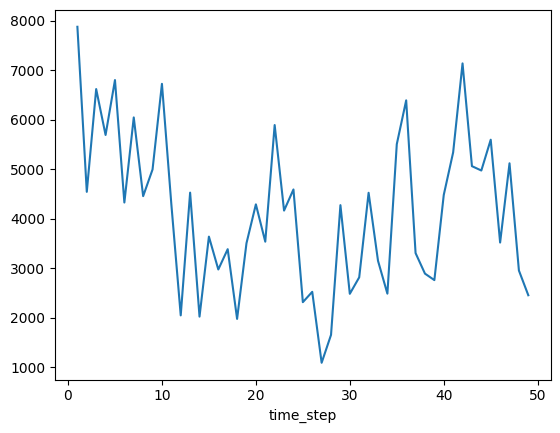

In [34]:
# temporal dist
df_nodes.groupby('time_step')['class'].count().plot()

In [35]:
# graph density
num_nodes = df_nodes.shape[0]
num_edges = df_edges.shape[0]
density = num_edges / (num_nodes * (num_nodes - 1))
print(f"Graph Density: {density:.6f}")
#sparse graph is excpected for real world networks, network is highly efficient.

Graph Density: 0.000006


In [36]:
df_labels['class'].value_counts()

,count
class,
unknown,157205
2,42019
1,4545


In [37]:
df_labels['class'].value_counts(normalize=True)

,proportion
class,
unknown,0.771486
2,0.206209
1,0.022305


In [38]:
df_labels.shape
df_features.shape

(203769, 167)

In [39]:
print("labels rows:", df_labels.shape)
print("features rows:", df_features.shape)

print("unique labels txId:", df_labels['txId'].nunique())
print("unique features txId:", df_features['txId'].nunique())

print("txIds in labels not in features:",
      df_labels.loc[~df_labels['txId'].isin(df_features['txId']), 'txId'].nunique())

print("txIds in features not in labels:",
      df_features.loc[~df_features['txId'].isin(df_labels['txId']), 'txId'].nunique())

labels rows: (203769, 2)
features rows: (203769, 167)
unique labels txId: 203769
unique features txId: 203769
txIds in labels not in features: 0
txIds in features not in labels: 0


In [ ]:
len(df_edges)/len(df_nodes)  # avg degree

1.1501013402431184

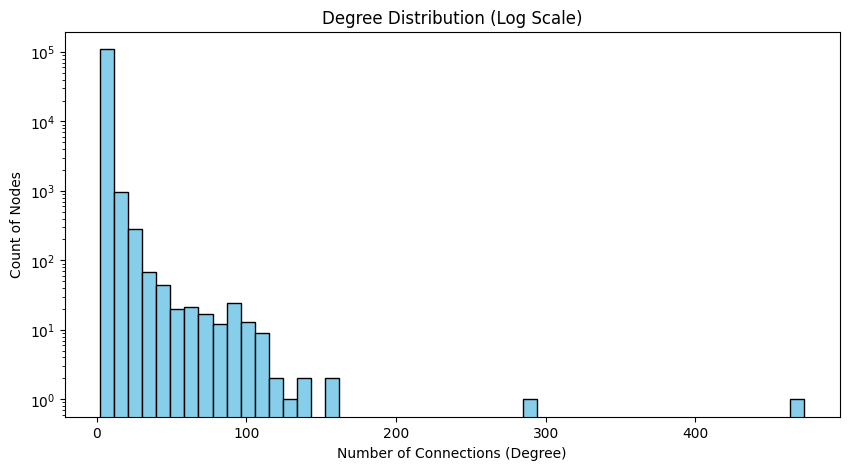

In [40]:
# Calculate degree for each node
# In-degree: how many transactions flow INTO this tx
# Out-degree: how many transactions flow OUT of this tx
degrees = df_edges['txId1'].value_counts() + df_edges['txId2'].value_counts()

plt.figure(figsize=(10, 5))
plt.hist(degrees, bins=50, log=True, color='skyblue', edgecolor='black')
plt.title("Degree Distribution (Log Scale)")
plt.xlabel("Number of Connections (Degree)")
plt.ylabel("Count of Nodes")
plt.show()

Interpreting with some context here:
- the average degree is 1.15ish, meaning that any node with a degree of 10, 20, or more, is likely a major outlier and this represents mixing services or consolidation points
- Because of sparsity, we should use GraphSAGE or GCN because it aggregates neighbors information without being overwhelmed by noise.

- Another thing, isolated clusters can be highly suspicious. There are a lot of disjointed clusters in this data. So, most nodes do not see each other. We need to rely on local neighborhood features because of this!

In [41]:
# 1. Create the Graph object from your edgelist
G = nx.from_pandas_edgelist(df_edges, source='txId1', target='txId2', create_using=nx.Graph())

# 2. Find all connected components
components = list(nx.connected_components(G))

# 3. Sort components by size (largest first)
components.sort(key=len, reverse=True)

# 4. Get the Largest Connected Component
lcc = G.subgraph(components[0])

print(f"Total nodes in full graph: {G.number_of_nodes()}")
print(f"Nodes in the Largest Connected Component: {lcc.number_of_nodes()}")
print(f"Percentage of nodes in LCC: {100 * lcc.number_of_nodes() / G.number_of_nodes():.2f}%")

Total nodes in full graph: 203769
Nodes in the Largest Connected Component: 7880
Percentage of nodes in LCC: 3.87%


In [42]:
# Create a mapping of txId to class for quick lookup
node_class_dict = dict(zip(df_nodes['txId'], df_nodes['class']))

# Analyze the top 10 largest components
for i, comp in enumerate(components[:10]):
    # Count classes in this component
    classes_in_comp = [node_class_dict.get(node, -1) for node in comp]

    fraud_count = classes_in_comp.count(1)
    licit_count = classes_in_comp.count(0)
    unknown_count = classes_in_comp.count(-1)

    print(f"Component {i+1} | Size: {len(comp)} | Fraud: {fraud_count} | Licit: {licit_count} | Unknown: {unknown_count}")

Component 1 | Size: 7880 | Fraud: 17 | Licit: 2130 | Unknown: 5733
Component 2 | Size: 7140 | Fraud: 239 | Licit: 1915 | Unknown: 4986
Component 3 | Size: 6803 | Fraud: 8 | Licit: 1874 | Unknown: 4921
Component 4 | Size: 6727 | Fraud: 18 | Licit: 954 | Unknown: 5755
Component 5 | Size: 6621 | Fraud: 11 | Licit: 1268 | Unknown: 5342
Component 6 | Size: 6393 | Fraud: 33 | Licit: 1675 | Unknown: 4685
Component 7 | Size: 6048 | Fraud: 102 | Licit: 1101 | Unknown: 4845
Component 8 | Size: 5894 | Fraud: 158 | Licit: 1605 | Unknown: 4131
Component 9 | Size: 5693 | Fraud: 30 | Licit: 1410 | Unknown: 4253
Component 10 | Size: 5598 | Fraud: 5 | Licit: 1216 | Unknown: 4377


In [ ]:
# we could use this to create risk scores for unknown nodes based on their proximity to known fraudulent nodes in the graph.

To self-labeling the unknown parts:  
1.	builds the graph  
2.	runs iterative label propagation with labeled nodes clamped  
3.	assigns pseudo-labels to unknown only when confidence is high (|score| >= threshold)  

In [43]:
#Use component structure to pseudo-label unknown nodes.
pseudo_labels = {}

for i, comp in enumerate(components):
    classes_in_comp = [node_class_dict.get(node, -1) for node in comp]

    fraud_count = classes_in_comp.count(1)
    licit_count = classes_in_comp.count(0)
    unknown_count = classes_in_comp.count(-1)

    # Only label if component is "pure"
    if fraud_count > 0 and licit_count == 0:
        for node in comp:
            if node_class_dict.get(node, -1) == -1:
                pseudo_labels[node] = 1

    elif licit_count > 0 and fraud_count == 0:
        # Licit-dominated component
        for node in comp:
            if node_class_dict.get(node, -1) == -1:
                pseudo_labels[node] = 0

print("Total pseudo-labeled nodes:", len(pseudo_labels))

Total pseudo-labeled nodes: 0


In [44]:
#Adjacency List
from collections import defaultdict

adj = defaultdict(set)

for _, row in df_edges.iterrows():
    adj[row['txId1']].add(row['txId2'])
    adj[row['txId2']].add(row['txId1'])

In [45]:
#Neighbor Majority Labeling
pseudo_labels = {}

for node in df_nodes['txId']:
    if node_class_dict.get(node, -1) == -1:  # unknown

        neighbors = adj[node]
        neighbor_labels = [node_class_dict.get(n, -1) for n in neighbors]

        fraud_count = neighbor_labels.count(1)
        licit_count = neighbor_labels.count(0)

        total_known = fraud_count + licit_count

        if total_known >= 3:  # require minimum neighbors
            fraud_ratio = fraud_count / total_known

            if fraud_ratio > 0.9:
                pseudo_labels[node] = 1
            elif fraud_ratio < 0.1:
                pseudo_labels[node] = 0

print("Total pseudo-labeled nodes:", len(pseudo_labels))

Total pseudo-labeled nodes: 2102


In [46]:
df_nodes["class_str"] = df_nodes["class"].astype(str).str.strip()

df_nodes["y"] = df_nodes["class_str"].map({
    "1": 1,
    "0": 0,
    "-1": -1
}).astype(int)

print("y counts fixed:\n", df_nodes["y"].value_counts(dropna=False))

y counts fixed:
 y
-1    157205
 0     42019
 1      4545
Name: count, dtype: int64


In [47]:
df_nodes["pseudo_y"] = df_nodes["y"]

# only fill unknowns using a vectorized map
mask_unknown = df_nodes["pseudo_y"] == -1
df_nodes.loc[mask_unknown, "pseudo_y"] = (
    df_nodes.loc[mask_unknown, "txId"]
    .map(pseudo_labels)        # dict works directly
    .fillna(-1)
    .astype(int)
)

print(df_nodes["pseudo_y"].value_counts(dropna=False))
print("Unknown remaining:", (df_nodes["pseudo_y"] == -1).sum())

pseudo_y
-1    155103
 0     43991
 1      4675
Name: count, dtype: int64
Unknown remaining: 155103


In [48]:
pseudo_series = pd.Series(pseudo_labels)
print("Pseudo label counts:")
print(pseudo_series.value_counts())

print("\nPseudo fraud rate:", (pseudo_series == 1).mean())

Pseudo label counts:
0    1972
1     130
Name: count, dtype: int64

Pseudo fraud rate: 0.06184586108468126


scale from 1-hop rules to multi-hop diffusion, and then use those pseudo labels to train a model and evaluate.

In [49]:
#Check how many pseudo labels are in training timeframe / graph coverage
print("Pseudo-labeled nodes:", len(pseudo_labels))
print("Pseudo labeled class distribution:", pd.Series(pseudo_labels).value_counts().to_dict())

#unknown remain
print("Unknown remaining:", (df_nodes["pseudo_y"] == -1).sum())

Pseudo-labeled nodes: 2102
Pseudo labeled class distribution: {0: 1972, 1: 130}
Unknown remaining: 155103


In [50]:
print("y counts:\n", df_nodes["y"].value_counts(dropna=False))
print("pseudo_y counts:\n", df_nodes["pseudo_y"].value_counts(dropna=False))
print("unknown remaining computed:", (df_nodes["pseudo_y"] == -1).sum())

y counts:
 y
-1    157205
 0     42019
 1      4545
Name: count, dtype: int64
pseudo_y counts:
 pseudo_y
-1    155103
 0     43991
 1      4675
Name: count, dtype: int64
unknown remaining computed: 155103


 The right next step is Label Propagation (multi-hop diffusion). It will give every node a continuous score, then you pseudo-label lots of confident licit nodes + a small capped set of fraud nodes.

In [51]:
# Run label propagation and create lp_score
# Build index
tx_ids = df_nodes["txId"].values
id_to_idx = {t:i for i,t in enumerate(tx_ids)}
n = len(tx_ids)

# Build undirected adjacency (sparse)
src = df_edges["txId1"].map(id_to_idx)
dst = df_edges["txId2"].map(id_to_idx)
mask = src.notna() & dst.notna()
src = src[mask].astype(int).values
dst = dst[mask].astype(int).values

row = np.concatenate([src, dst])
col = np.concatenate([dst, src])
data = np.ones(len(row), dtype=np.float32)
A = sparse.csr_matrix((data, (row, col)), shape=(n, n))

deg = np.array(A.sum(axis=1)).ravel()
deg[deg == 0] = 1.0
Dinv = sparse.diags(1.0 / deg)

# Seeds: fraud=+1, licit=-1, unknown=0
y0 = np.zeros(n, dtype=np.float32)
y0[df_nodes["y"].values == 1] =  1.0
y0[df_nodes["y"].values == 0] = -1.0
labeled = y0 != 0

alpha = 0.95
y = y0.copy()

for _ in range(50):
    y_new = alpha * (Dinv @ (A @ y)) + (1 - alpha) * y0
    y_new[labeled] = y0[labeled]  # clamp
    y = y_new

df_nodes["lp_score"] = y
df_nodes["lp_conf"] = np.abs(y)

df_nodes[["lp_score","lp_conf"]].describe()

,lp_score,lp_conf
count,203769.000000,203769.000000
mean,-0.529887,0.616827
std,0.472371,0.351187
min,-1.000000,0.000000
25%,-0.950000,0.305662
50%,-0.639253,0.696887
75%,-0.221334,0.950000
max,1.000000,1.000000


	•	lp_score close to +1 → fraud-like
	•	close to -1 → licit-like
	•	near 0 → uncertain

In [52]:
# Convert LP scores → pseudo labels with thresholds + fraud cap
unknown = df_nodes["pseudo_y"].values == -1  # only label remaining unknowns

# Licit: threshold on negative score
licit_thr = 0.90
pseudo_licit = unknown & (df_nodes["lp_score"].values <= -licit_thr)

# Fraud: take top-K unknown by lp_score
K = 500
fraud_rank = df_nodes.loc[unknown, "lp_score"].sort_values(ascending=False)
topk_idx = fraud_rank.head(K).index

df_nodes["pseudo_y_lp"] = df_nodes["pseudo_y"]  # start from neighbor-majority result
df_nodes.loc[pseudo_licit, "pseudo_y_lp"] = 0
df_nodes.loc[topk_idx, "pseudo_y_lp"] = 1

print("pseudo_y_lp counts:\n", df_nodes["pseudo_y_lp"].value_counts(dropna=False))
print("Added licit:", (df_nodes["pseudo_y_lp"].eq(0) & unknown).sum())
print("Added fraud:", (df_nodes["pseudo_y_lp"].eq(1) & unknown).sum())
print("Unknown remaining:", (df_nodes["pseudo_y_lp"] == -1).sum())

pseudo_y_lp counts:
 pseudo_y_lp
-1    134066
 0     64528
 1      5175
Name: count, dtype: int64
Added licit: 20537
Added fraud: 500
Unknown remaining: 134066


Train baseline (true label)

In [53]:
# Feature columns
feature_cols = [c for c in df_nodes.columns if c.startswith("feat_")]

# Only use true labels
known = df_nodes["y"].isin([0,1])

X = df_nodes.loc[known, feature_cols]
y = df_nodes.loc[known, "y"]

X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

baseline = Pipeline([
    ("scaler", StandardScaler(with_mean=False)),
    ("clf", LogisticRegression(max_iter=2000, class_weight="balanced"))
])

baseline.fit(X_tr, y_tr)
p_base = baseline.predict_proba(X_te)[:,1]

print("BASE AUC:", roc_auc_score(y_te, p_base))
print("BASE PR-AUC:", average_precision_score(y_te, p_base))

BASE AUC: 0.9662546097541691
BASE PR-AUC: 0.7573374161151372


Train semi-supervised model (true + LP pseudo)

In [54]:
# Use final pseudo labels
pseudo_train = (df_nodes["y"] == -1) & df_nodes["pseudo_y_lp"].isin([0,1])

X_p = df_nodes.loc[pseudo_train, feature_cols]
y_p = df_nodes.loc[pseudo_train, "pseudo_y_lp"]

X_tr2 = pd.concat([X_tr, X_p], axis=0)
y_tr2 = pd.concat([y_tr, y_p], axis=0)

semi = Pipeline([
    ("scaler", StandardScaler(with_mean=False)),
    ("clf", LogisticRegression(max_iter=2000, class_weight="balanced"))
])

semi.fit(X_tr2, y_tr2)
p_semi = semi.predict_proba(X_te)[:,1]

print("SEMI AUC:", roc_auc_score(y_te, p_semi))
print("SEMI PR-AUC:", average_precision_score(y_te, p_semi))

SEMI AUC: 0.9549776967225518
SEMI PR-AUC: 0.6643143598878953


While graph-based label propagation substantially increases labeled coverage, incorporating pseudo labels into supervised training can degrade performance due to noise and class imbalance effects.

In [55]:
# Build training set: true train + pseudo
X_tr2 = pd.concat([X_tr, X_p], axis=0)
y_tr2 = pd.concat([y_tr, y_p], axis=0)

# Sample weights: 1.0 for true labels, w for pseudo labels
w = 0.2  # try 0.1, 0.2, 0.3
sw = np.ones(len(y_tr2), dtype=float)
sw[len(y_tr):] = w  # pseudo part

semi_w = Pipeline([
    ("scaler", StandardScaler(with_mean=False)),
    ("clf", LogisticRegression(max_iter=2000, class_weight="balanced"))
])

semi_w.fit(X_tr2, y_tr2, clf__sample_weight=sw)
p_semi_w = semi_w.predict_proba(X_te)[:, 1]

print("SEMI (weighted) AUC:", roc_auc_score(y_te, p_semi_w))
print("SEMI (weighted) PR-AUC:", average_precision_score(y_te, p_semi_w))

SEMI (weighted) AUC: 0.9621445128806074
SEMI (weighted) PR-AUC: 0.7049529515937906


Graph-based label propagation increases label coverage. However, pseudo labels are imperfect. Treating them as equal to true labels degrades fraud detection.Confidence weighting mitigates performance drop.